In [2]:
# Load Oil & Gas dataset and prepare SLB/XOM closes
import os, glob
import pandas as pd
import kagglehub

OIL_DATASET_DIR = kagglehub.dataset_download("prasertk/oil-and-gas-stock-prices")
print("Oil & Gas dataset dir:", OIL_DATASET_DIR)

# Find a CSV that contains Date/Symbol/Close
csv_candidates = sorted(glob.glob(os.path.join(OIL_DATASET_DIR, "**", "*.csv"), recursive=True))
assert csv_candidates, f"No CSV files found in {OIL_DATASET_DIR}"

def pick_column(columns, candidates):
    return next((c for c in candidates if c in columns), None)

selected_csv = None
for fp in csv_candidates:
    try:
        sample = pd.read_csv(fp, nrows=5)
    except Exception:
        continue
    cols = list(sample.columns)
    if pick_column(cols, ["Date", "date", "DateTime", "datetime"]) and \
       pick_column(cols, ["Symbol", "symbol", "Ticker", "ticker"]) and \
       pick_column(cols, ["Adj Close", "adj_close", "Close", "close"]):
        selected_csv = fp
        break

assert selected_csv is not None, "Could not locate a CSV with Date/Symbol/Close columns"
print("Using CSV:", os.path.basename(selected_csv))

df = pd.read_csv(selected_csv)

date_col = pick_column(df.columns, ["Date", "date", "DateTime", "datetime"]) 
symbol_col = pick_column(df.columns, ["Symbol", "symbol", "Ticker", "ticker"]) 
close_col = pick_column(df.columns, ["Adj Close", "adj_close", "Close", "close"]) 

# Normalize and filter
df = df[[date_col, symbol_col, close_col]].copy()
df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)
df = df.dropna(subset=[date_col])

mask = df[symbol_col].astype(str).str.upper().isin(["SLB", "XOM"])
df = df.loc[mask]

pivot = (df
    .sort_values(date_col)
    .dropna(subset=[close_col])
    .pivot_table(index=date_col, columns=df[symbol_col].str.upper(), values=close_col, aggfunc="last")
    .sort_index()
)

prices = pivot[["SLB", "XOM"]].dropna()

# Train/Test split: train <= 2019-12-31, test >= 2020-01-01
TRAIN_CUTOFF = pd.Timestamp("2019-12-31")
prices_train = prices.loc[prices.index <= TRAIN_CUTOFF]
prices_test = prices.loc[prices.index >= TRAIN_CUTOFF + pd.Timedelta(days=1)]

print("prices:", prices.shape, "train:", prices_train.shape, "test:", prices_test.shape)
prices_train.head()


/opt/homebrew/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Oil & Gas dataset dir: /Users/alexandergu/.cache/kagglehub/datasets/prasertk/oil-and-gas-stock-prices/versions/1
Using CSV: oil and gas stock prices.csv
prices: (5647, 2) train: (5031, 2) test: (616, 2)


/var/folders/1x/tv12jhzn42v59pvt5mwf16q00000gn/T/ipykernel_16011/1855879809.py:40: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)


Symbol,SLB,XOM
Date,,
2000-01-03,27.47,39.16
2000-01-04,27.09,38.41
2000-01-05,27.03,40.50
2000-01-06,28.88,42.59
2000-01-07,29.41,42.47


(5031, 8)


/var/folders/1x/tv12jhzn42v59pvt5mwf16q00000gn/T/ipykernel_16011/1940229589.py:11: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  _df_all[_date_col] = pd.to_datetime(_df_all[_date_col], errors="coerce", infer_datetime_format=True)


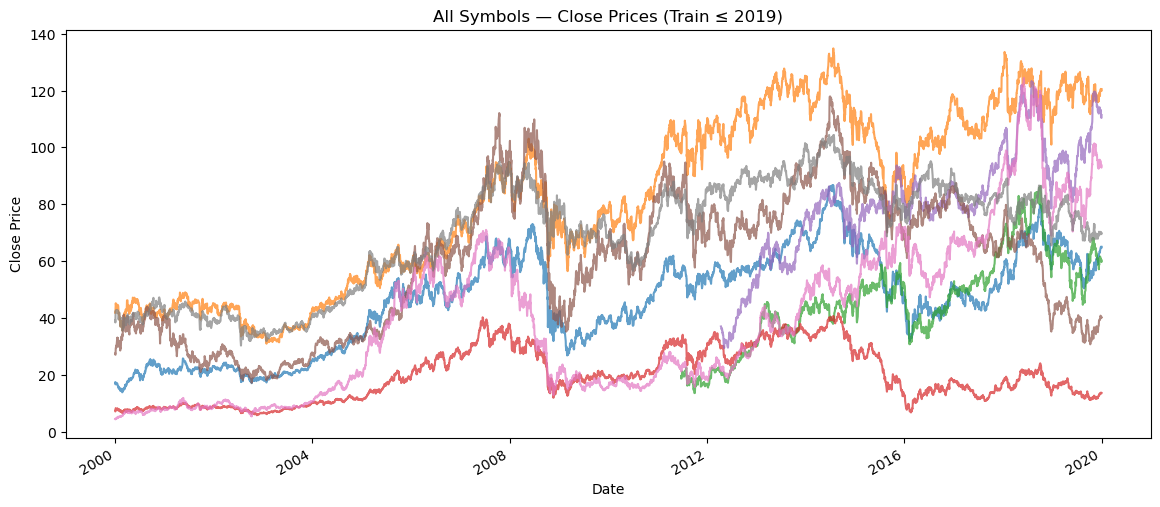

In [3]:
# Build all-symbols close price pivot (train only) and plot
# Reuse selected_csv from earlier step
_df_all = pd.read_csv(selected_csv)

# Detect columns again for robustness
_date_col = pick_column(_df_all.columns, ["Date", "date", "DateTime", "datetime"]) 
_symbol_col = pick_column(_df_all.columns, ["Symbol", "symbol", "Ticker", "ticker"]) 
_close_col = pick_column(_df_all.columns, ["Adj Close", "adj_close", "Close", "close"]) 

_df_all = _df_all[[_date_col, _symbol_col, _close_col]].copy()
_df_all[_date_col] = pd.to_datetime(_df_all[_date_col], errors="coerce", infer_datetime_format=True)
_df_all = _df_all.dropna(subset=[_date_col])

prices_all = (_df_all
    .sort_values(_date_col)
    .dropna(subset=[_close_col])
    .pivot_table(index=_date_col, columns=_df_all[_symbol_col].astype(str).str.upper(), values=_close_col, aggfunc="last")
    .sort_index()
)

# Train subset for all symbols
prices_all_train = prices_all.loc[prices_all.index <= TRAIN_CUTOFF]
print(prices_all_train.shape)

fig, ax = plt.subplots(figsize=(14, 6))
prices_all_train.plot(ax=ax, legend=False, alpha=0.7)
ax.set_title("All Symbols — Close Prices (Train ≤ 2019)")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price")
plt.show()



In [4]:
# Rank pairs by mean-crossing counts (train)
import numpy as np
import pandas as pd
from itertools import combinations

pairs = []
cols = prices_all_train.columns.tolist()
train_years = (prices_all_train.index[-1] - prices_all_train.index[0]).days / 365.25

for a, b in combinations(cols, 2):
    diff = (prices_all_train[a] - prices_all_train[b]).dropna()
    if diff.empty:
        continue
    centered = diff - diff.mean()
    # Count zero-crossings (sign changes). Ignore exact zeros by nudging or dropping.
    s = np.sign(centered.values)
    # Remove zeros by carrying forward previous sign
    for i in range(1, len(s)):
        if s[i] == 0:
            s[i] = s[i-1]
    crossings = int(np.sum(s[1:] * s[:-1] < 0))
    per_year = crossings / max(train_years, 1e-9)
    pairs.append({
        "pair": f"{a}-{b}",
        "crossings": crossings,
        "crossings_per_year": per_year,
        "n": int(len(centered))
    })

crossings_df = (pd.DataFrame(pairs)
    .sort_values(["crossings_per_year", "crossings", "n"], ascending=[False, False, False])
    .reset_index(drop=True))

print("Top mean-crossing pairs (train):\n", crossings_df.head(10))
crossings_df.head(10)


Top mean-crossing pairs (train):
       pair  crossings  crossings_per_year     n
0  SLB-XOM        128            6.402629  5031
1  COP-SLB        118            5.902424  5031
2  COP-XOM        114            5.702342  5031
3  COP-MRO        107            5.352198  5031
4  CVX-SLB         89            4.451828  5031
5  MRO-SLB         86            4.301767  5031
6  VLO-XOM         77            3.851582  5031
7  COP-CVX         69            3.451417  5031
8  PSX-VLO         69            3.451417  1942
9  MPC-PSX         59            2.951212  1942


,pair,crossings,crossings_per_year,n
0,SLB-XOM,128,6.402629,5031
1,COP-SLB,118,5.902424,5031
2,COP-XOM,114,5.702342,5031
3,COP-MRO,107,5.352198,5031
4,CVX-SLB,89,4.451828,5031
5,MRO-SLB,86,4.301767,5031
6,VLO-XOM,77,3.851582,5031
7,COP-CVX,69,3.451417,5031
8,PSX-VLO,69,3.451417,1942
9,MPC-PSX,59,2.951212,1942


In [5]:
# Rank cointegration across top symbols (train only)
from itertools import combinations
from statsmodels.tsa.stattools import coint
import numpy as np
import pandas as pd

# Choose a manageable symbol universe (most frequent symbols, drop too-sparse)
valid_counts = prices_all_train.count()
top_symbols = (valid_counts
    .sort_values(ascending=False)
    .head(20)
    .index.tolist())

sub = prices_all_train[top_symbols].dropna()

results = []
for a, b in combinations(sub.columns, 2):
    y = sub[a]
    x = sub[b]
    try:
        score, pvalue, crit = coint(y, x)
    except Exception:
        continue
    # Estimate hedge ratio via OLS (with intercept)
    X = sm.add_constant(x)
    model = sm.OLS(y, X, missing='drop').fit()
    alpha = float(model.params['const']) if 'const' in model.params else 0.0
    beta = float(model.params[x.name])
    resid = y - (alpha + beta * x)
    # AR(1) half-life estimate
    resid_lag = resid.shift(1).dropna()
    delta = (resid - resid_lag).dropna()
    if len(delta) < 10:
        continue
    X_ar = sm.add_constant(resid_lag.loc[delta.index])
    ar = sm.OLS(delta, X_ar).fit()
    phi = ar.params.get(resid_lag.name, np.nan)
    if pd.isna(phi) or phi >= 0:
        half_life = np.inf
    else:
        half_life = np.log(2) / -phi
    results.append({
        'pair': f"{a}-{b}",
        'pvalue': pvalue,
        'beta_a_on_b': beta,
        'half_life_days': float(half_life),
        'samples': int(len(resid.dropna()))
    })

ranked = (pd.DataFrame(results)
    .sort_values(['pvalue', 'half_life_days', 'samples'], ascending=[True, True, False])
    .reset_index(drop=True))

print("Top cointegration candidates (train):\n", ranked.head(10))
ranked.head(10)


Top cointegration candidates (train):
       pair    pvalue  beta_a_on_b  half_life_days  samples
0  XOM-PSX  0.064321    -0.169793             inf     1942
1  XOM-MPC  0.067345    -0.251702             inf     1942
2  VLO-XOM  0.100657    -1.622836             inf     1942
3  SLB-XOM  0.122196     1.893627             inf     1942
4  VLO-MPC  0.169866     1.579714             inf     1942
5  VLO-PSX  0.179761     1.153871             inf     1942
6  MRO-XOM  0.200035     0.900575             inf     1942
7  CVX-SLB  0.212723    -0.009735             inf     1942
8  CVX-MRO  0.236705     0.521511             inf     1942
9  CVX-VLO  0.240012     0.105795             inf     1942


,pair,pvalue,beta_a_on_b,half_life_days,samples
0,XOM-PSX,0.064321,-0.169793,inf,1942
1,XOM-MPC,0.067345,-0.251702,inf,1942
2,VLO-XOM,0.100657,-1.622836,inf,1942
3,SLB-XOM,0.122196,1.893627,inf,1942
4,VLO-MPC,0.169866,1.579714,inf,1942
5,VLO-PSX,0.179761,1.153871,inf,1942
6,MRO-XOM,0.200035,0.900575,inf,1942
7,CVX-SLB,0.212723,-0.009735,inf,1942
8,CVX-MRO,0.236705,0.521511,inf,1942
9,CVX-VLO,0.240012,0.105795,inf,1942


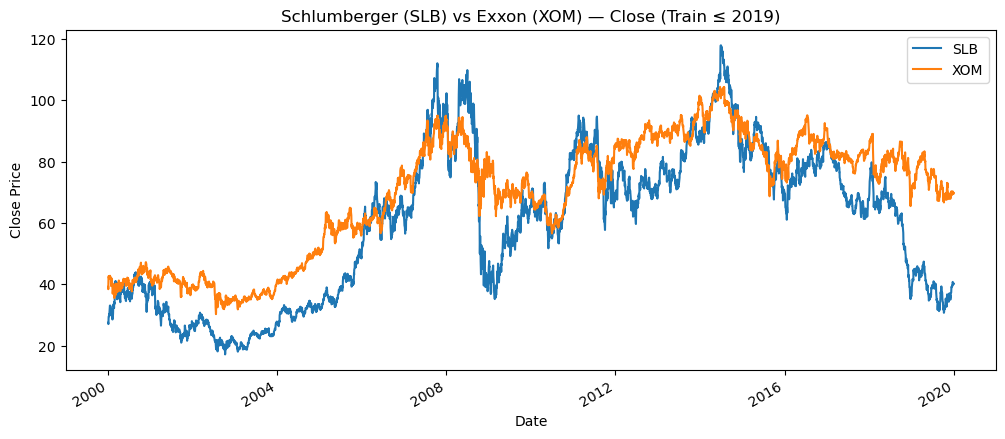

In [6]:
# Plot closes over time (SLB vs XOM) — Train only
fig, ax = plt.subplots(figsize=(12, 5))
prices_train[["SLB", "XOM"]].plot(ax=ax)
ax.set_title("Schlumberger (SLB) vs Exxon (XOM) — Close (Train ≤ 2019)")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price")
ax.legend(["SLB", "XOM"])
plt.show()


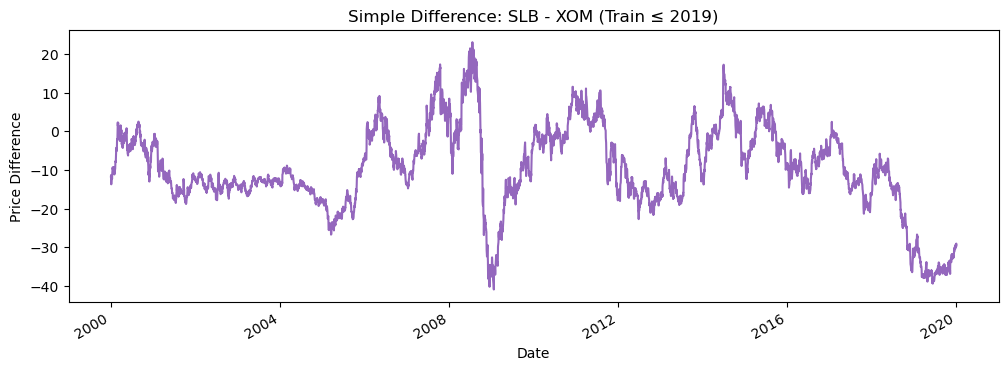

In [7]:
# Plot difference: SLB minus XOM close — Train only
spread_simple = prices_train["SLB"] - prices_train["XOM"]
fig, ax = plt.subplots(figsize=(12, 4))
spread_simple.plot(ax=ax, color="tab:purple")
ax.set_title("Simple Difference: SLB - XOM (Train ≤ 2019)")
ax.set_xlabel("Date")
ax.set_ylabel("Price Difference")
plt.show()


/var/folders/1x/tv12jhzn42v59pvt5mwf16q00000gn/T/ipykernel_16011/3035360775.py:11: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(spread_train.index, _fit_line, color="black", linewidth=2.0, label="Best-fit line")


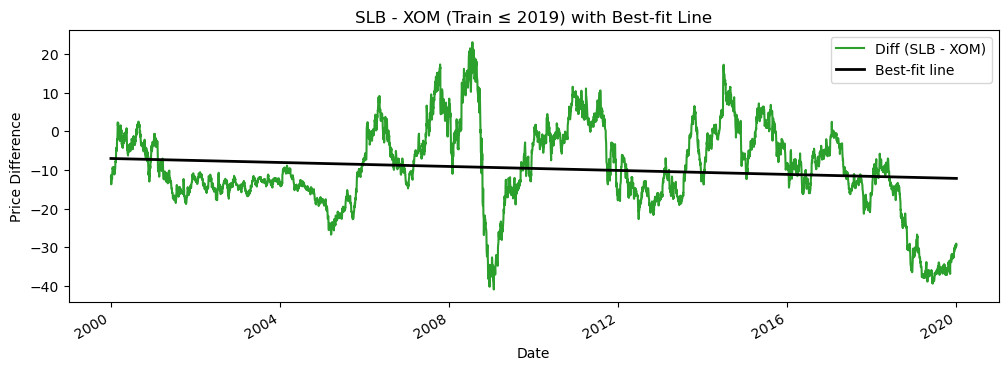

Slope (drift): -0.000706 per day (~-0.18 per trading year)


In [8]:
# Plot train-period best-fit line and slope (no 2016 cutoff)
spread_train = spread_simple  # already train-only

# Linear fit over the full train period
_t_days = (spread_train.index - spread_train.index[0]).days.values.astype(float)
_slope_per_day, _intercept = np.polyfit(_t_days, spread_train.values, 1)
_fit_line = _slope_per_day * _t_days + _intercept

fig, ax = plt.subplots(figsize=(12, 4))
spread_train.plot(ax=ax, color="tab:green", label="Diff (SLB - XOM)")
ax.plot(spread_train.index, _fit_line, color="black", linewidth=2.0, label="Best-fit line")
ax.set_title("SLB - XOM (Train ≤ 2019) with Best-fit Line")
ax.set_xlabel("Date")
ax.set_ylabel("Price Difference")
ax.legend()
plt.show()

print(f"Slope (drift): {_slope_per_day:.6f} per day (~{_slope_per_day*252:.2f} per trading year)")


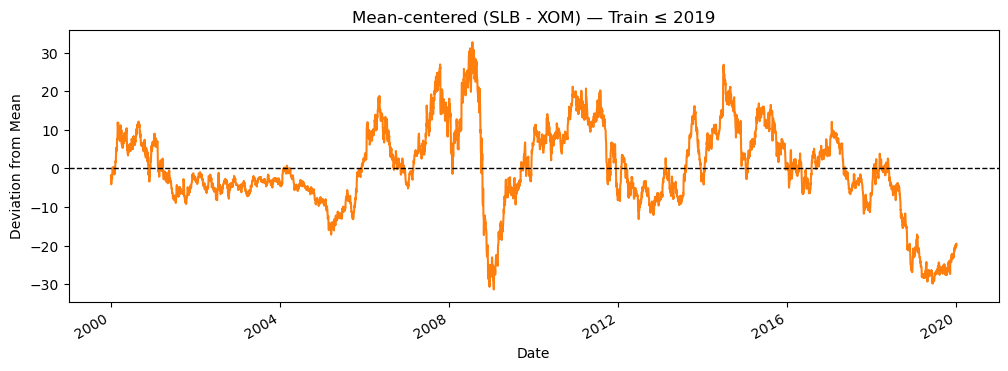

In [9]:
# Plot mean-centered difference: (SLB - XOM) over full train period
# Center by subtracting the mean of the train-period difference
residual = spread_train - spread_train.mean()

fig, ax = plt.subplots(figsize=(12, 4))
residual.plot(ax=ax, color="tab:orange")
ax.axhline(0.0, color="black", linewidth=1, linestyle="--")
ax.set_title("Mean-centered (SLB - XOM) — Train ≤ 2019")
ax.set_xlabel("Date")
ax.set_ylabel("Deviation from Mean")
plt.show()

#beta_a_on_b = 1.893627


Hedge ratio (beta): 1.118, alpha: -17.781
Strategy (train):
- Enter LONG spread: z <= -1.0  → long SLB, short 1.12× XOM
- Enter SHORT spread: z >= +1.0 → short SLB, long 1.12× XOM
- Exit when z crosses 0 back toward mean
Signals: 70 long entries, 63 short entries, 132 exits


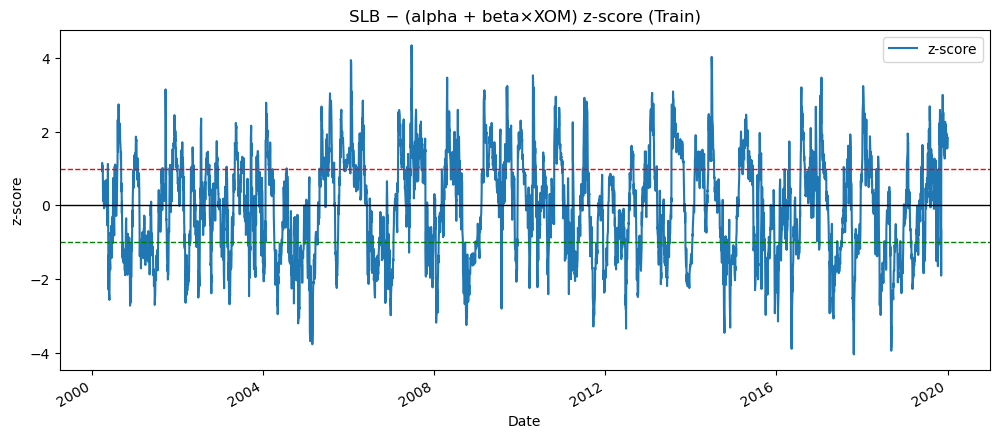

In [53]:
# SLB–XOM strategy: hedge-ratio spread, z-score signals, and plot (train only)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pair_a, pair_b = "SLB", "XOM"
assert pair_a in prices_train.columns and pair_b in prices_train.columns

# Align series
_df = pd.concat({pair_a: prices_train[pair_a], pair_b: prices_train[pair_b]}, axis=1).dropna()
y = _df[pair_a]
x = _df[pair_b]

# OLS hedge ratio: y ~ alpha + beta*x
X = sm.add_constant(x)
ols = sm.OLS(y, X).fit()
alpha = float(ols.params["const"]) if "const" in ols.params else 0.0
beta = float(ols.params[x.name])

# Hedged spread and rolling z-score
spread = y - (alpha + beta * x)
z_window = 60
z = (spread - spread.rolling(z_window).mean()) / spread.rolling(z_window).std()

# Trading rules (mean-reversion): enter when |z| > entry, exit when z crosses 0
entry_z = 1.0
exit_to_zero = True

position = []  # +1: long y/short beta*x; -1: short y/long beta*x; 0: flat
state = 0
for t, zt in z.items():
    if np.isnan(zt):
        position.append(state)
        continue
    if state == 0:
        if zt <= -entry_z:
            state = 1
        elif zt >= entry_z:
            state = -1
    elif state == 1:
        if exit_to_zero and zt >= 0:
            state = 0
    elif state == -1:
        if exit_to_zero and zt <= 0:
            state = 0
    position.append(state)

pos = pd.Series(position, index=z.index).astype(int)

long_entries = int(((pos == 1) & (pos.shift(1).fillna(0) == 0)).sum())
short_entries = int(((pos == -1) & (pos.shift(1).fillna(0) == 0)).sum())
round_trips = int(((pos == 0) & (pos.shift(1).abs() == 1)).sum())

print(f"Hedge ratio (beta): {beta:.3f}, alpha: {alpha:.3f}")
print("Strategy (train):")
print(f"- Enter LONG spread: z <= -{entry_z:.1f}  → long {pair_a}, short {beta:.2f}× {pair_b}")
print(f"- Enter SHORT spread: z >= +{entry_z:.1f} → short {pair_a}, long {beta:.2f}× {pair_b}")
print("- Exit when z crosses 0 back toward mean")
print(f"Signals: {long_entries} long entries, {short_entries} short entries, {round_trips} exits")

# Plot z-score and bands
fig, ax = plt.subplots(figsize=(12, 5))
z.plot(ax=ax, color="tab:blue", label="z-score")
ax.axhline(0, color="black", linewidth=1)
ax.axhline(entry_z, color="red", linestyle="--", linewidth=1)
ax.axhline(-entry_z, color="green", linestyle="--", linewidth=1)
ax.set_title(f"{pair_a} − (alpha + beta×{pair_b}) z-score (Train)")
ax.set_ylabel("z-score")
ax.legend()
plt.show()


Fitted (static) hedge: alpha=-17.7812, beta=1.1180
Train: annRet=1.33%, annVol=11.80%, Sharpe=0.11, win%=14.1%
Test (OOS): annRet=7.88%, annVol=13.60%, Sharpe=0.58, win%=11.7%
Events (Train): kill_shock= 2 kill_legret= 8 stop_entry_long= 0 stop_abs_long= 36 stop_entry_short= 0 stop_abs_short= 27
Events (Test): kill_shock= 0 kill_legret= 1 stop_entry_long= 0 stop_abs_long= 7 stop_entry_short= 0 stop_abs_short= 0


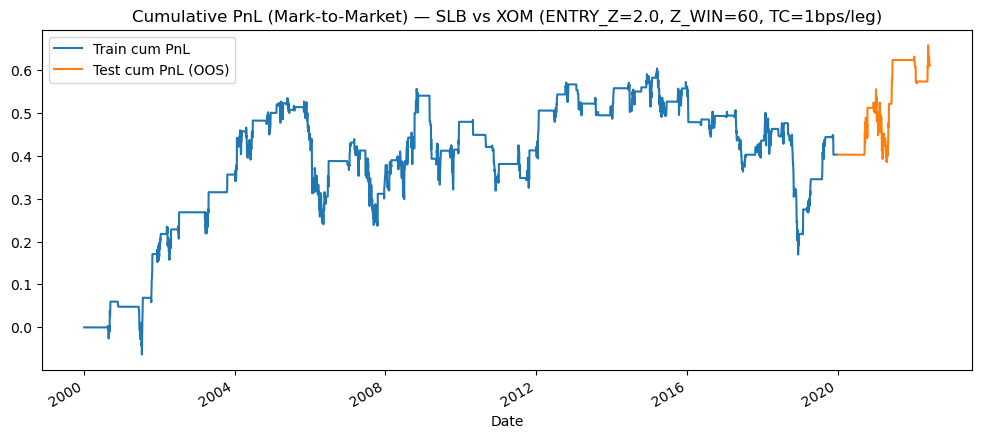

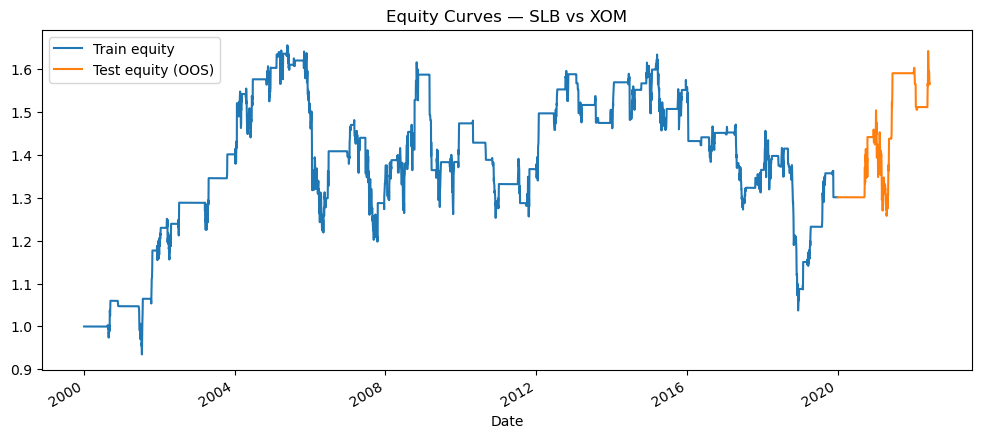

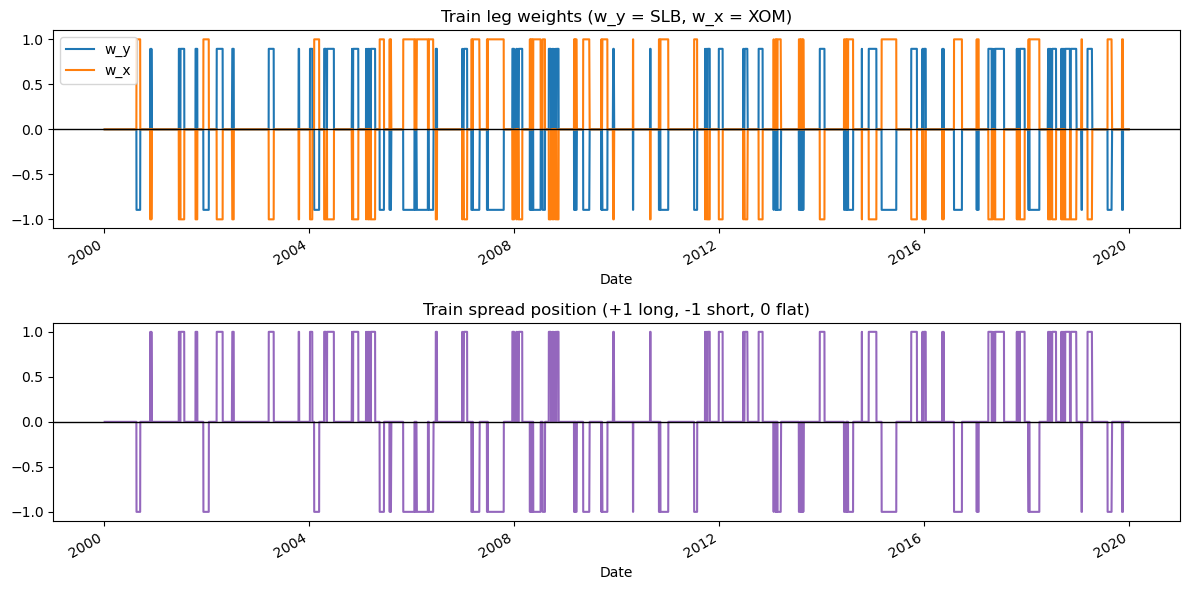

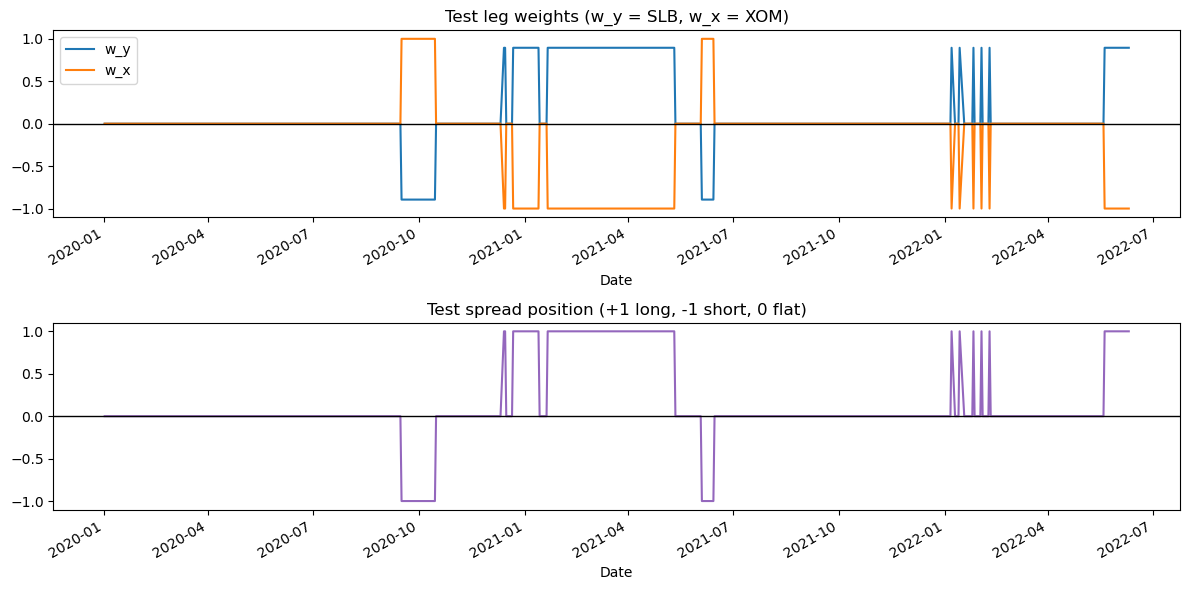

In [ ]:
# Backtest SLB–XOM mean-reversion: train fit, OOS apply
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from typing import Union

PAIR_A, PAIR_B = "SLB", "XOM"
ENTRY_Z = 2.0      # entry threshold (z-score)
EXIT_Z = 0.0       # exit threshold (closer to mean)
STOP_Z = 3.0       # hard stop if adverse z beyond this
Z_WIN = 60
TC_BPS = 1         # per leg, round-trip ~2*TC_BPS
NOTIONAL = 1.0     # base notional per leg before caps
MAX_LEG = 1.0      # cap absolute position per leg
MAX_GROSS = 2.0    # cap |w_y| + |w_x| per day
CONFIRM_BARS = 2   # require z beyond entry for N consecutive bars to enter
MIN_HOLD_DAYS = 0  # minimum holding period before allowing exit
MAX_HOLD_DAYS = 0  # hard cap on holding period (0 disables)
KILL_Z_JUMP = 2.5   # flatten if |Δz| exceeds this
SUSPEND_DAYS = 3    # after a kill, don’t re-enter for N days
LEG_RET_KILL = 0.08  # flatten if either leg |daily return| ≥ threshold
COOLDOWN_DAYS = 3  # cooldown after exit before re-entry

# Entry condition style
ENTER_ON_MEANWARD_CROSS = False   # require mean-ward band cross to enter

# Manual hedge ratio override (set True to use alpha=0, beta=1)
MANUAL_HEDGE = False
MANUAL_ALPHA = -5.0
MANUAL_BETA = 1.0

# Rolling hedge settings
USE_ROLLING_HEDGE = False
ROLL_WIN = 60        # window length for rolling OLS
ROLL_MIN_PERIODS = 30 # min samples to estimate rolling hedge
ROLL_INCLUDE_CONST = False  # include intercept in rolling regression

# Helper to compute hedge ratio on a given df
def fit_hedge_ratio(df: pd.DataFrame) -> tuple[float, float]:
    y = df[PAIR_A]
    x = df[PAIR_B]
    X = sm.add_constant(x)
    model = sm.OLS(y, X, missing='drop').fit()
    alpha = float(model.params.get('const', 0.0))
    beta = float(model.params[x.name])
    return alpha, beta

# Rolling OLS hedge ratio (alpha and beta) using vectorized moments
# Uses only past data up to each timestamp (no look-ahead)
def compute_rolling_hedge(
    df: pd.DataFrame,
    window: int,
    min_periods: int,
    include_const: bool = True,
) -> tuple[pd.Series, pd.Series]:
    y = df[PAIR_A].astype(float)
    x = df[PAIR_B].astype(float)

    if include_const:
        ex = x.rolling(window, min_periods=min_periods).mean()
        ey = y.rolling(window, min_periods=min_periods).mean()
        exx = (x * x).rolling(window, min_periods=min_periods).mean()
        exy = (x * y).rolling(window, min_periods=min_periods).mean()
        varx = exx - ex * ex
        covxy = exy - ex * ey
        beta = covxy / varx.replace(0.0, np.nan)
        alpha = ey - beta * ex
    else:
        sum_xy = (x * y).rolling(window, min_periods=min_periods).sum()
        sum_xx = (x * x).rolling(window, min_periods=min_periods).sum()
        beta = sum_xy / sum_xx.replace(0.0, np.nan)
        alpha = pd.Series(0.0, index=df.index)

    return alpha, beta

# Build signals and returns on a given df using fixed or rolling alpha/beta
HedgeParam = Union[float, pd.Series]

def run_strategy(df: pd.DataFrame, alpha: HedgeParam, beta: HedgeParam) -> pd.DataFrame:
    y = df[PAIR_A]
    x = df[PAIR_B]

    # Align scalar/series hedge params to df index
    if isinstance(alpha, (int, float)):
        alpha_aligned = pd.Series(float(alpha), index=df.index)
    else:
        alpha_aligned = alpha.reindex(df.index).astype(float)
    if isinstance(beta, (int, float)):
        beta_aligned = pd.Series(float(beta), index=df.index)
    else:
        beta_aligned = beta.reindex(df.index).astype(float)

    spread = y - (alpha_aligned + beta_aligned * x)

    # Robust z option: median/MAD fallback via parameters
    use_robust = True
    if use_robust:
        roll = spread.rolling(Z_WIN)
        median = roll.median()
        mad = (roll.apply(lambda s: np.median(np.abs(s - np.median(s))), raw=False) * 1.4826)
        z = (spread - median) / mad.replace(0, np.nan)
    else:
        z = (spread - spread.rolling(Z_WIN).mean()) / spread.rolling(Z_WIN).std()
    z_diff = z.diff().fillna(0.0)
    z_prev = z.shift(1)

    # Leg daily returns for kill-switch
    ry = y.pct_change().fillna(0.0)
    rx = x.pct_change().fillna(0.0)

    # Position logic with hysteresis, confirmation, min-hold, and cooldown
    state = 0
    pos = []
    confirm_long = 0
    confirm_short = 0
    hold = 0
    cooldown = 0
    suspend = 0
    z_entry = np.nan  # z at time of entry, to measure reversion progress

    # Event tracking and counters
    event = []
    kill_shock_count = 0
    kill_legret_count = 0
    stop_entry_long = 0
    stop_abs_long = 0
    stop_entry_short = 0
    stop_abs_short = 0
    entry_long_count = 0
    entry_short_count = 0

    for (t, zt), dz in zip(z.items(), z_diff):
        evt = ""
        if np.isnan(zt):
            pos.append(state)
            event.append(evt)
            continue
        # Decrement timers if active
        if cooldown > 0:
            cooldown -= 1
        if suspend > 0:
            suspend -= 1
        # Shock kill-switch: flatten if sudden jump in z
        if state != 0 and (abs(dz) >= KILL_Z_JUMP):
            kill_shock_count += 1
            evt = 'kill_shock'
            state = 0
            cooldown = COOLDOWN_DAYS
            suspend = SUSPEND_DAYS
            hold = 0
            z_entry = np.nan
        # Leg return kill-switch
        if state != 0 and (abs(ry.loc[t]) >= LEG_RET_KILL or abs(rx.loc[t]) >= LEG_RET_KILL):
            kill_legret_count += 1
            evt = 'kill_legret'
            state = 0
            cooldown = COOLDOWN_DAYS
            suspend = max(suspend, SUSPEND_DAYS)
            hold = 0
            z_entry = np.nan
        if state == 0:
            hold = 0
            if cooldown > 0 or suspend > 0:
                pos.append(0)
                event.append(evt)
                continue
            if ENTER_ON_MEANWARD_CROSS:
                prev = z_prev.loc[t]
                if not np.isnan(prev) and (prev <= -ENTRY_Z) and (zt > -ENTRY_Z):
                    state = 1
                    entry_long_count += 1
                    evt = 'entry_long'
                    confirm_long = 0
                    confirm_short = 0
                    hold = 0
                    z_entry = zt
                elif not np.isnan(prev) and (prev >= ENTRY_Z) and (zt < ENTRY_Z):
                    state = -1
                    entry_short_count += 1
                    evt = 'entry_short'
                    confirm_short = 0
                    confirm_long = 0
                    hold = 0
                    z_entry = zt
            else:
                # Confirmed entries with reversion tick: require small reversal toward mean
                REVERT_TICK = 0.05
                if zt <= -ENTRY_Z:
                    confirm_long += 1
                else:
                    confirm_long = 0
                if zt >= ENTRY_Z:
                    confirm_short += 1
                else:
                    confirm_short = 0
                if confirm_long >= CONFIRM_BARS and dz > REVERT_TICK:  # z rising toward mean
                    state = 1
                    entry_long_count += 1
                    evt = 'entry_long'
                    confirm_long = 0
                    confirm_short = 0
                    hold = 0
                    z_entry = zt
                elif confirm_short >= CONFIRM_BARS and dz < -REVERT_TICK:  # z falling toward mean
                    state = -1
                    entry_short_count += 1
                    evt = 'entry_short'
                    confirm_short = 0
                    confirm_long = 0
                    hold = 0
                    z_entry = zt
        elif state == 1:
            hold += 1
            confirm_long = 0
            confirm_short = 0
            # z-from-entry stop: if z moves further away from entry by > STOP_Z, exit
            if not np.isnan(z_entry) and (zt - z_entry) <= -STOP_Z:
                stop_entry_long += 1
                evt = 'stop_entry_long'
                state = 0
                cooldown = COOLDOWN_DAYS
                hold = 0
                z_entry = np.nan
            # Stop-loss for long if spread keeps going against us (absolute z)
            elif zt <= -STOP_Z:
                stop_abs_long += 1
                evt = 'stop_abs_long'
                state = 0
                cooldown = COOLDOWN_DAYS
                hold = 0
                z_entry = np.nan
            # Exit long when sufficiently back toward mean and min-hold satisfied (reverted)
            elif hold >= MIN_HOLD_DAYS and zt >= EXIT_Z:
                state = 0
                cooldown = COOLDOWN_DAYS
                hold = 0
                z_entry = np.nan
            # Max holding period
            elif MAX_HOLD_DAYS and hold >= MAX_HOLD_DAYS:
                state = 0
                cooldown = COOLDOWN_DAYS
                hold = 0
                z_entry = np.nan
        elif state == -1:
            hold += 1
            confirm_long = 0
            confirm_short = 0
            # z-from-entry stop for short: if z moves further away by > STOP_Z, exit
            if not np.isnan(z_entry) and (zt - z_entry) >= STOP_Z:
                stop_entry_short += 1
                evt = 'stop_entry_short'
                state = 0
                cooldown = COOLDOWN_DAYS
                hold = 0
                z_entry = np.nan
            # Stop-loss for short if spread keeps going against us (absolute z)
            elif zt >= STOP_Z:
                stop_abs_short += 1
                evt = 'stop_abs_short'
                state = 0
                cooldown = COOLDOWN_DAYS
                hold = 0
                z_entry = np.nan
            # Exit short when sufficiently back toward mean and min-hold satisfied (reverted)
            elif hold >= MIN_HOLD_DAYS and zt <= -EXIT_Z:
                state = 0
                cooldown = COOLDOWN_DAYS
                hold = 0
                z_entry = np.nan
            # Max holding period
            elif MAX_HOLD_DAYS and hold >= MAX_HOLD_DAYS:
                state = 0
                cooldown = COOLDOWN_DAYS
                hold = 0
                z_entry = np.nan
        pos.append(state)
        event.append(evt)
    pos = pd.Series(pos, index=z.index).astype(int)

    # Dollar-neutral PnL using simple close-to-close returns
    ry = y.pct_change().fillna(0.0)
    rx = x.pct_change().fillna(0.0)

    # Position sizes before caps: long spread => +1 in y, -beta in x; short spread => -1 in y, +beta in x
    base_y = pos.astype(float) * NOTIONAL
    base_x = -beta_aligned * pos.astype(float) * NOTIONAL

    # Preserve hedge ratio under caps via a single scale per timestamp
    abs_by = base_y.abs()
    abs_bx = base_x.abs()
    with np.errstate(divide='ignore', invalid='ignore'):
        scale_leg_y = (MAX_LEG / abs_by).where(abs_by > 0, other=np.inf)
        scale_leg_x = (MAX_LEG / abs_bx).where(abs_bx > 0, other=np.inf)
        gross_base = abs_by + abs_bx
        scale_gross = (MAX_GROSS / gross_base).where(gross_base > 0, other=np.inf)
    scale = pd.concat([scale_leg_y, scale_leg_x, scale_gross], axis=1).min(axis=1)
    scale = scale.clip(upper=1.0).replace([np.inf, -np.inf], 1.0).fillna(1.0)

    w_y = base_y * scale
    w_x = base_x * scale

    # Transaction costs proportional to turnover of leg weights (bps * traded notional)
    # Mark-to-market: do not force final flatten; charge only on actual turnover
    dw = w_y.diff().abs().fillna(0.0) + w_x.diff().abs().fillna(0.0)
    tc = (TC_BPS / 10000.0) * dw

    # Mark-to-market PnL via units × price change
    units_y = w_y.shift(1) / y.shift(1).replace(0, np.nan)
    units_x = w_x.shift(1) / x.shift(1).replace(0, np.nan)
    price_dy = y.diff().fillna(0.0)
    price_dx = x.diff().fillna(0.0)
    pnl = (units_y * price_dy) + (units_x * price_dx) - tc
    pnl = pnl.fillna(0.0)

    cum_pnl = pnl.cumsum()
    eq = (1.0 + pnl).cumprod()

    return pd.DataFrame({
        'spread': spread,
        'z': z,
        'event': pd.Series(event, index=z.index),
        'pos': pos,
        'w_y': w_y,
        'w_x': w_x,
        'units_y': units_y,
        'units_x': units_x,
        'gross': (w_y.abs() + w_x.abs()),
        'pnl': pnl,
        'cum_pnl': cum_pnl,
        'equity': eq,
        'kill_shock_count': pd.Series(kill_shock_count, index=z.index),
        'kill_legret_count': pd.Series(kill_legret_count, index=z.index),
        'stop_entry_long_count': pd.Series(stop_entry_long, index=z.index),
        'stop_abs_long_count': pd.Series(stop_abs_long, index=z.index),
        'stop_entry_short_count': pd.Series(stop_entry_short, index=z.index),
        'stop_abs_short_count': pd.Series(stop_abs_short, index=z.index),
        'entry_long_count': pd.Series(entry_long_count, index=z.index),
        'entry_short_count': pd.Series(entry_short_count, index=z.index),
    })

# Prepare train/test frames
train_df = prices_train[[PAIR_A, PAIR_B]].dropna()
test_df = prices_test[[PAIR_A, PAIR_B]].dropna()

# Fit on train (or override), run on train and OOS
if MANUAL_HEDGE:
    alpha_tr, beta_tr = MANUAL_ALPHA, MANUAL_BETA
    fit_label = 'Manual (override)'
elif USE_ROLLING_HEDGE:
    # Rolling fit on train, then extend through test using only prior data (no look-ahead)
    alpha_series_tr, beta_series_tr = compute_rolling_hedge(
        train_df, window=ROLL_WIN, min_periods=ROLL_MIN_PERIODS, include_const=ROLL_INCLUDE_CONST
    )
    # For test, compute on concatenated history and then slice test
    if len(test_df):
        combined = pd.concat([train_df, test_df])
        alpha_series_all, beta_series_all = compute_rolling_hedge(
            combined, window=ROLL_WIN, min_periods=ROLL_MIN_PERIODS, include_const=ROLL_INCLUDE_CONST
        )
        alpha_series_te = alpha_series_all.reindex(test_df.index)
        beta_series_te = beta_series_all.reindex(test_df.index)
    else:
        alpha_series_te = pd.Series(dtype=float, index=test_df.index)
        beta_series_te = pd.Series(dtype=float, index=test_df.index)
    fit_label = f'Rolling(window={ROLL_WIN}, min={ROLL_MIN_PERIODS})'
else:
    alpha_tr, beta_tr = fit_hedge_ratio(train_df)
    fit_label = 'Fitted (static)'

# Run strategies
if USE_ROLLING_HEDGE and not MANUAL_HEDGE:
    res_tr = run_strategy(train_df, alpha_series_tr, beta_series_tr)
    res_te = run_strategy(test_df, alpha_series_te, beta_series_te) if len(test_df) else pd.DataFrame()
else:
    res_tr = run_strategy(train_df, alpha_tr, beta_tr)
    res_te = run_strategy(test_df, alpha_tr, beta_tr) if len(test_df) else pd.DataFrame()

# Metrics
def metrics(res: pd.DataFrame, label: str):
    if res.empty:
        print(f"{label}: no data")
        return
    pnl = res['pnl']
    ann_ret = (res['equity'].iloc[-1]) ** (252/len(res)) - 1 if len(res) > 0 else 0
    ann_vol = pnl.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    wins = (pnl > 0).mean()
    print(f"{label}: annRet={ann_ret:.2%}, annVol={ann_vol:.2%}, Sharpe={sharpe:.2f}, win%={wins:.1%}")

if MANUAL_HEDGE:
    print(f"{fit_label} hedge: alpha={MANUAL_ALPHA:.4f}, beta={MANUAL_BETA:.4f}")
elif USE_ROLLING_HEDGE:
    last_alpha = alpha_series_tr.dropna().iloc[-1] if len(alpha_series_tr.dropna()) else np.nan
    last_beta = beta_series_tr.dropna().iloc[-1] if len(beta_series_tr.dropna()) else np.nan
    print(f"{fit_label} — last(train) alpha={last_alpha:.4f}, beta={last_beta:.4f}")
else:
    print(f"{fit_label} hedge: alpha={alpha_tr:.4f}, beta={beta_tr:.4f}")

metrics(res_tr, "Train")
metrics(res_te, "Test (OOS)")

# Print aggregated event counts
if not res_tr.empty:
    print("Events (Train):",
          "entry_long=", int(res_tr['event'].eq('entry_long').sum()),
          "entry_short=", int(res_tr['event'].eq('entry_short').sum()),
          "kill_shock=", int(res_tr['event'].eq('kill_shock').sum()),
          "kill_legret=", int(res_tr['event'].eq('kill_legret').sum()),
          "stop_entry_long=", int(res_tr['event'].eq('stop_entry_long').sum()),
          "stop_abs_long=", int(res_tr['event'].eq('stop_abs_long').sum()),
          "stop_entry_short=", int(res_tr['event'].eq('stop_entry_short').sum()),
          "stop_abs_short=", int(res_tr['event'].eq('stop_abs_short').sum()))
if not res_te.empty:
    print("Events (Test):",
          "entry_long=", int(res_te['event'].eq('entry_long').sum()),
          "entry_short=", int(res_te['event'].eq('entry_short').sum()),
          "kill_shock=", int(res_te['event'].eq('kill_shock').sum()),
          "kill_legret=", int(res_te['event'].eq('kill_legret').sum()),
          "stop_entry_long=", int(res_te['event'].eq('stop_entry_long').sum()),
          "stop_abs_long=", int(res_te['event'].eq('stop_abs_long').sum()),
          "stop_entry_short=", int(res_te['event'].eq('stop_entry_short').sum()),
          "stop_abs_short=", int(res_te['event'].eq('stop_abs_short').sum()))

# Plot equity and cumulative PnL curves
fig, ax = plt.subplots(figsize=(12, 5))
res_tr['cum_pnl'].plot(ax=ax, label='Train cum PnL')
if not res_te.empty:
    # Stack OOS cum PnL after train
    res_te_shifted = res_te['cum_pnl'] + res_tr['cum_pnl'].iloc[-1]
    res_te_shifted.plot(ax=ax, label='Test cum PnL (OOS)')
ax.set_title(f"Cumulative PnL (Mark-to-Market) — {PAIR_A} vs {PAIR_B} (ENTRY_Z={ENTRY_Z}, Z_WIN={Z_WIN}, TC={TC_BPS}bps/leg)")
ax.legend()
plt.show()

# Still show equity curves for reference
fig, ax = plt.subplots(figsize=(12, 5))
res_tr['equity'].plot(ax=ax, label='Train equity')
if not res_te.empty:
    res_te_aligned = res_te['equity'] * res_tr['equity'].iloc[-1]
    res_te_aligned.plot(ax=ax, label='Test equity (OOS)')
ax.set_title(f"Equity Curves — {PAIR_A} vs {PAIR_B}")
ax.legend()
plt.show()

# Positions plots (in the same cell)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)
res_tr[['w_y','w_x']].plot(ax=axes[0])
axes[0].set_title('Train leg weights (w_y = SLB, w_x = XOM)')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].legend()

res_tr['pos'].plot(ax=axes[1], color='tab:purple')
axes[1].set_title('Train spread position (+1 long, -1 short, 0 flat)')
axes[1].axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

if not res_te.empty:
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)
    res_te[['w_y','w_x']].plot(ax=axes[0])
    axes[0].set_title('Test leg weights (w_y = SLB, w_x = XOM)')
    axes[0].axhline(0, color='black', linewidth=1)
    axes[0].legend()

    res_te['pos'].plot(ax=axes[1], color='tab:purple')
    axes[1].set_title('Test spread position (+1 long, -1 short, 0 flat)')
    axes[1].axhline(0, color='black', linewidth=1)
    plt.tight_layout()
    plt.show()
